In [1]:
import pandas as pd
import sqlite3

In [2]:
connection = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
df = pd.read_sql("SELECT timestamp as datetime FROM checker WHERE uid LIKE 'user%'", connection)
df

,datetime
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370
...,...
3202,2020-05-21 20:19:06.872761
3203,2020-05-21 20:22:41.785725
3204,2020-05-21 20:22:41.877806
3205,2020-05-21 20:37:00.129678


In [4]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.dayofweek
df['day_type'] = df['weekday'].apply(
    lambda x: 'weekend' if x >= 5 else 'working_day'
)

In [5]:
daily_hourly_commits = df.groupby(['date', 'hour', 'day_type']).size().reset_index(name='commits')

avg_commits_per_hour = daily_hourly_commits.groupby(['hour', 'day_type'])['commits'].mean().reset_index(name='avg_commits')
avg_commits_per_hour

,hour,day_type,avg_commits
0,0,weekend,2.000000
1,0,working_day,3.000000
2,1,weekend,6.000000
3,3,weekend,1.000000
4,3,working_day,2.000000
5,5,weekend,2.000000
6,5,working_day,7.500000
7,6,working_day,1.500000
8,7,weekend,4.000000
9,7,working_day,5.166667


In [6]:
avg_commits_per_hour = avg_commits_per_hour.pivot(index='hour', columns='day_type', values='avg_commits').reset_index()
avg_commits_per_hour.columns = ['hour','weekend', 'working_day']
avg_commits_per_hour = avg_commits_per_hour.set_index('hour')
avg_commits_per_hour = avg_commits_per_hour.reindex(range(24)).fillna(0)
avg_commits_per_hour

,weekend,working_day
hour,,
0,2.000000,3.000000
1,6.000000,0.000000
2,0.000000,0.000000
3,1.000000,2.000000
4,0.000000,0.000000
5,2.000000,7.500000
6,0.000000,1.500000
7,4.000000,5.166667
8,7.000000,3.700000


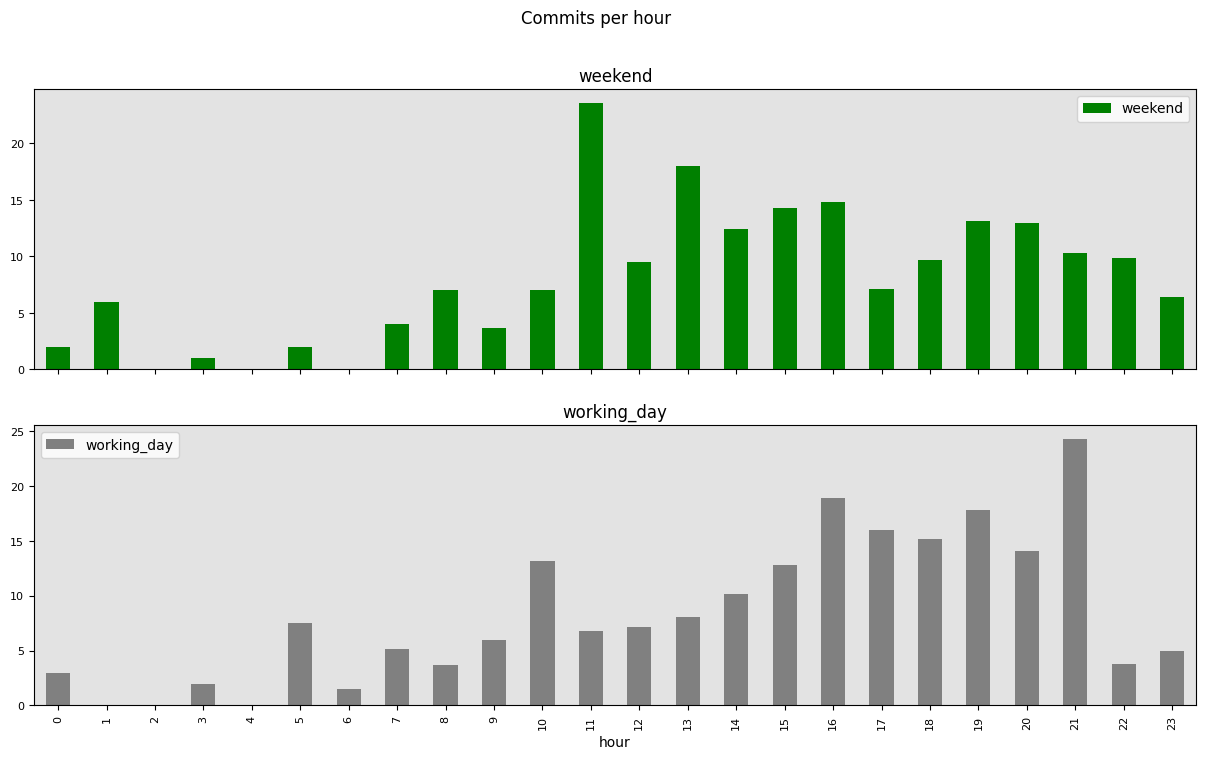

In [7]:
ax = avg_commits_per_hour.plot(
    kind='bar',
    subplots=True,
    figsize=(15,8),
    fontsize=8,
    color=['green', 'grey'],
    title='Commits per hour'
)

ax[0].grid(False)
ax[1].grid(False)

ax[0].set_facecolor('#E3E3E3')
ax[1].set_facecolor('#E3E3E3')

In [8]:
connection.close()

«Отличается ли динамика в рабочие и выходные дни?» Для ответа укажите час, когда количество коммитов максимально в рабочие дни, и час, когда оно максимально в выходные.

**Да: 21, 11**